## Setup

In [1]:
import pandas as pd
import numpy as np
import os
from langchain_community.document_loaders import PyPDFLoader, UnstructuredPDFLoader, PyPDFium2Loader
from langchain.document_loaders import PyPDFDirectoryLoader, DirectoryLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from pathlib import Path
import random
import ollama
import networkx as nx
import hypernetx as hnx 
import matplotlib.pyplot as plt



## Input data directory
data_dir = "PFAS_test"
inputdirectory = Path(f"./data_input/{data_dir}")
## This is where the output csv files will be written
out_dir = data_dir
outputdirectory = Path(f"./data_output/{out_dir}")

## Load Documents

In [2]:
## Dir PDF Loader
#loader = PyPDFDirectoryLoader(inputdirectory)
## File Loader
#loader = PyPDFLoader("./data/MedicalDocuments/orf-path_health-n1.pdf")
loader = DirectoryLoader(inputdirectory, show_progress=True)
documents = loader.load()

100%|██████████| 1/1 [00:01<00:00,  1.21s/it]


## Extract Concepts

In [3]:
## This function uses the helpers/prompt function to extract concepts from text
from helpers.df_helpers import docs2Graph
from helpers.df_helpers import docs2Hypergraph

# Standard KG generation

If regenerate is set to True then the dataframes are regenerated and Both the dataframes are written in the csv format so we dont have to calculate them again. 

        dfne = dataframe of edges

        df = dataframe of chunks


Else the dataframes are read from the output directory

In [4]:
# To regenerate the graph with LLM, set this to True
regenerate = False

if regenerate:
    # Generate concepts list from full text documents (no chunking)
   # G_graph = docs2Graph(documents, model='codellama:13b-instruct')
    G_graph = docs2Graph(documents, model='mistral:instruct')
    # Convert to DataFrame from the graph
    dfg1 = nx.to_pandas_edgelist(G_graph)
    #save the graph
    nx.write_graphml(G_graph, "output_graph.graphml")

else: 
    G_graph = nx.read_graphml("output_graph.graphml")
    dfg1 = nx.to_pandas_edgelist(G_graph)

In [9]:
print(type(G_graph))
print(f"Generated graph with {G_graph.number_of_nodes()} nodes and {G_graph.number_of_edges()} edges.")

NameError: name 'G_graph' is not defined

# Hypergraph Generation

In [ ]:
"""
import pickle
import pandas as pd

# To regenerate the hypergraph with LLM, set this to True
regenerate = True

if regenerate:
    # Generate hypergraph from full text documents
    H_hypergraph = docs2Hypergraph(documents, model='mistral:instruct')
    
    # Save as pickle (recommended format for HyperNetX)
    with open("output_hypergraph.pkl", "wb") as f:
        pickle.dump(H_hypergraph, f)

    # Optional: convert hyperedges to DataFrame
    dfg1 = pd.DataFrame([
        {"event": hedge, "entity": node}
        for hedge, nodes in H_hypergraph.incidence_dict.items()
        for node in nodes
    ])

    # Save DataFrame for inspection
    dfg1.to_csv("output_hypergraph_edges.csv", index=False)

else:
    # Load from pickle
    with open("output_hypergraph.pkl", "rb") as f:
        H_hypergraph = pickle.load(f)

    # Reconstruct DataFrame
    dfg1 = pd.DataFrame([
        {"event": hedge, "entity": node}
        for hedge, nodes in H_hypergraph.incidence_dict.items()
        for node in nodes
    ])
"""

Generating hypergraph events...
 [
  {
    "id": "PDMS and carbon black combine to create a flexible, piezoresistive matrix ideal for embedding strain sensors in load-bearing tissue constructs.",
    "entities": ["PDMS", "carbon black"]
  },
  {
    "id": "The mechanical resilience of engineered bone grafts relies on the interplay between iron(II) sulfate, hydrogen peroxide, and pH buffering agents during oxidative crosslinking of matrix proteins.",
    "entities": ["iron(II) sulfate", "hydrogen peroxide", "pH buffering agents"]
  },
  {
    "id": "Zinc oxide and lactic acid work together to promote antibacterial activity and osteoinductivity in bioresorbable scaffold coatings.",
    "entities": ["Zinc oxide", "lactic acid"]
  },
  {
    "id": "Polyethylene oxide, lithium salt, ceramic nanoparticles, and plasticizers together produce a solid polymer electrolyte useful for biosensing applications integrated into smart bone implants.",
    "entities": ["Polyethylene oxide", "lithium salt

AttributeError: 'tuple' object has no attribute 'incidence_dict'

In [18]:
import pickle
import pandas as pd

# To regenerate the hypergraph with LLM, set this to True
regenerate = False

if regenerate:
    # Generate hypergraph and mapping from full text documents
    H_hypergraph, edge_mapping = docs2Hypergraph(documents, model='mistral:instruct')
    
    # Save as pickle
    with open("output_hypergraph_test.pkl", "wb") as f:
        pickle.dump(H_hypergraph, f)

    # Convert hyperedges to DataFrame
    dfg1 = pd.DataFrame([
        {"event": hedge, "entity": node}
        for hedge, nodes in H_hypergraph.incidence_dict.items()
        for node in nodes
    ])

    # Save CSV
    dfg1.to_csv("output_hypergraph_edges_test.csv", index=False)

else:
    # Load from pickle
    with open("output_hypergraph_test.pkl", "rb") as f:
        H_hypergraph = pickle.load(f)

    # Reconstruct DataFrame
    dfg1 = pd.DataFrame([
        {"event": hedge, "entity": node}
        for hedge, nodes in H_hypergraph.incidence_dict.items()
        for node in nodes
    ])


In [19]:
print(type(H_hypergraph))
print(f"Generated hypergraph with {len(H_hypergraph.nodes)} nodes and {len(H_hypergraph.edges)} hyperedges.")

<class 'hypernetx.classes.hypergraph.Hypergraph'>
Generated hypergraph with 39 nodes and 32 hyperedges.


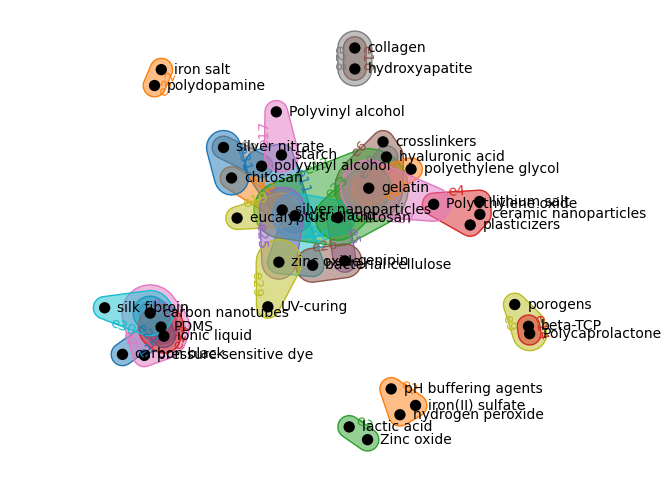

In [38]:
plt.figure(figsize=(8, 6))
hnx.draw(H_hypergraph, fill_edges=True, node_label_alpha=0.0, edge_label_alpha=0.0)
plt.savefig("hypergraph_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
H = H_hypergraph
H.incidences.dataframe

weight misc_properties
edges nodes                                      
e1    carbon black            1.0              {}
      PDMS                    1.0              {}
e2    hydrogen peroxide       1.0              {}
      pH buffering agents     1.0              {}
      iron(II) sulfate        1.0              {}
...                           ...             ...
e30   silk fibroin            1.0              {}
e31   chitosan                1.0              {}
      silver nitrate          1.0              {}
e32   iron salt               1.0              {}
      polydopamine            1.0              {}

[74 rows x 2 columns]

#  Node Degree
## Where a node's degree is defined as the number of hyperedges it participates in

In [23]:
from collections import defaultdict

# Build node → list of incident edges mapping
node_to_edges = defaultdict(set)

for edge_id, nodes in H_hypergraph.incidence_dict.items():
    for node in nodes:
        node_to_edges[node].add(edge_id)

# Now compute node degrees
node_degrees = {node: len(edges) for node, edges in node_to_edges.items()}

for node, degree in node_degrees.items():
    print(f"{node}: {degree}")

carbon black: 1
PDMS: 4
citric acid: 3
bacterial cellulose: 2
zinc oxide: 3
polyvinyl alcohol: 2
starch: 2
chitosan: 2
silver nanoparticles: 4
Chitosan: 4
gelatin: 6
Polycaprolactone: 2
beta-TCP: 2
carbon nanotubes: 4
collagen: 2
hydroxyapatite: 2
Polyvinyl alcohol: 1
hyaluronic acid: 2
eucalyptus oil: 1
hydrogen peroxide: 1
pH buffering agents: 1
iron(II) sulfate: 1
ionic liquid: 3
polyethylene glycol: 1
genipin: 2
Polyethylene oxide: 2
UV-curing: 1
Zinc oxide: 1
lactic acid: 1
silk fibroin: 1
silver nitrate: 2
iron salt: 1
polydopamine: 1
lithium salt: 1
plasticizers: 1
ceramic nanoparticles: 1
crosslinkers: 1
pressure-sensitive dye: 1
porogens: 1


# Edge Size
## size of each hyperedge

In [24]:
H = H_hypergraph
edge_sizes = {e: len(H.edges[e]) for e in H.edges}

for edge, size in edge_sizes.items():
    print(f"{edge}: {size}")

e1: 2
e2: 3
e3: 2
e4: 4
e5: 2
e6: 3
e7: 4
e8: 2
e9: 3
e10: 3
e11: 3
e12: 2
e13: 3
e14: 2
e15: 2
e16: 2
e17: 2
e18: 2
e19: 2
e20: 2
e21: 2
e22: 2
e23: 2
e24: 2
e25: 2
e26: 2
e27: 2
e28: 2
e29: 2
e30: 2
e31: 2
e32: 2


In [25]:
dist = H.distance('gelatin', 'chitosan', s=1)
print(f"Distance between gelatin and chitosan: {dist}")

Distance between gelatin and chitosan: 2


In [26]:
from hypernetx.algorithms.s_centrality_measures import (
    s_betweenness_centrality,
    s_closeness_centrality
)
import pandas as pd

# Compute s=1 centralities
s = 1

# Compute centralities
bet_centrality = s_betweenness_centrality(H, s=s)
close_centrality = s_closeness_centrality(H, s=s)

# Combine into a DataFrame
df = pd.DataFrame([
    {
        "Event": node,
        "S-Betweenness Centrality": bet_centrality.get(node, 0.0),
        "S-Closeness Centrality": close_centrality.get(node, 0.0)
    }
    for node in set(bet_centrality) | set(close_centrality)
])

# Sort by S-Betweenness Centrality
df_sorted = df.sort_values(by="S-Betweenness Centrality", ascending=False).reset_index(drop=True)

# Display as table
print("\n=== S-CENTRALITY MEASURES (sorted by S-Betweenness) ===")
print(df_sorted.to_string(index=False))




=== S-CENTRALITY MEASURES (sorted by S-Betweenness) ===
Event  S-Betweenness Centrality  S-Closeness Centrality
  e13                  0.126882                0.642857
  e20                  0.063799                0.545455
  e11                  0.061649                0.450000
  e25                  0.037634                0.529412
  e27                  0.036559                0.461538
  e10                  0.036559                0.473684
  e12                  0.035125                0.486486
  e23                  0.034050                0.545455
   e5                  0.018996                0.486486
  e31                  0.011470                0.375000
   e8                  0.008602                0.346154
  e15                  0.002509                1.000000
   e7                  0.002509                1.000000
  e26                  0.001792                0.391304
  e21                  0.000717                0.833333
  e24                  0.000717                

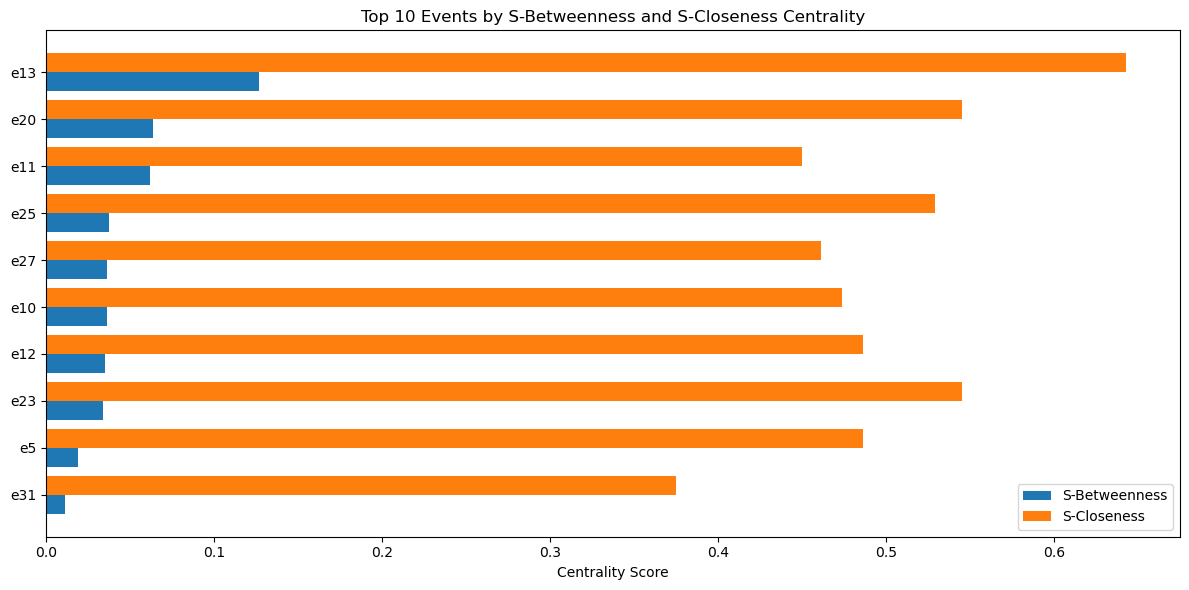

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
from hypernetx.algorithms.s_centrality_measures import (
    s_betweenness_centrality,
    s_closeness_centrality
)

# Compute s=1 centralities
s = 1
bet_centrality = s_betweenness_centrality(H, s=s)
close_centrality = s_closeness_centrality(H, s=s)

# Combine into a DataFrame
df = pd.DataFrame([
    {
        "Event": node,
        "S-Betweenness Centrality": bet_centrality.get(node, 0.0),
        "S-Closeness Centrality": close_centrality.get(node, 0.0)
    }
    for node in set(bet_centrality) | set(close_centrality)
])

# Sort and take top N
N = 10  # Change this number as desired
df_top = df.sort_values(by="S-Betweenness Centrality", ascending=False).head(N)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.4
x = range(len(df_top))

# Plot bars
ax.barh([i + bar_width for i in x], df_top["S-Betweenness Centrality"], bar_width, label="S-Betweenness")
ax.barh(x, df_top["S-Closeness Centrality"], bar_width, label="S-Closeness")

# Labeling
ax.set_yticks([i + bar_width / 2 for i in x])
ax.set_yticklabels(df_top["Event"])
ax.invert_yaxis()
ax.set_xlabel("Centrality Score")
ax.set_title(f"Top {N} Events by S-Betweenness and S-Closeness Centrality")
ax.legend()
plt.tight_layout()
plt.show()


In [27]:
import networkx as nx
from hypernetx.algorithms.s_centrality_measures import (
    s_harmonic_centrality,
    s_eccentricity
)
import pandas as pd

# Set the s-walk parameter
s = 1

# Compute S-Harmonic Centrality (works fine even if disconnected)
harm_centrality = s_harmonic_centrality(H, s=s)

# Try computing eccentricity, handle disconnected graphs gracefully
try:
    ecc_centrality = s_eccentricity(H, s=s)
except nx.NetworkXError:
    print("Graph is disconnected. Falling back to component-wise eccentricity.")
    linegraph = H.get_linegraph(s=s)
    ecc_centrality = {}
    for component in nx.connected_components(linegraph.to_undirected()):
        subgraph = linegraph.subgraph(component)
        ecc = nx.eccentricity(subgraph)
        ecc_centrality.update(ecc)

# Combine into a table
df = pd.DataFrame([
    {
        "Event": node,
        "S-Harmonic Centrality": harm_centrality.get(node, 0.0),
        "S-Eccentricity": ecc_centrality.get(node, float("inf"))
    }
    for node in set(harm_centrality) | set(ecc_centrality)
])

df = df.sort_values(by="S-Harmonic Centrality", ascending=False)
print(df)




Graph is disconnected. Falling back to component-wise eccentricity.
                                                Event  S-Harmonic Centrality  \
26  Chitosan, silver nanoparticles, and gelatin fu...              11.583333   
28  Chitosan and citric acid together reinforce po...              11.000000   
24  Chitosan, gelatin, calcium phosphate, and glyc...              10.916667   
6   Bacterial cellulose, citric acid, zinc oxide, ...              10.833333   
19  Chitosan and genipin crosslink to form a bioco...              10.250000   
3   Only when polyvinyl alcohol, citric acid, and ...               9.500000   
2   Polyethylene oxide and gelatin, when combined ...               9.366667   
14  Bacterial cellulose and genipin, reinforced wi...               9.000000   
0   Without gelatin, hyaluronic acid, and freeze-t...               8.866667   
7   The cryogel network suitable for bone defect f...               8.866667   
17  Polyvinyl alcohol, starch, and zinc oxide blen..

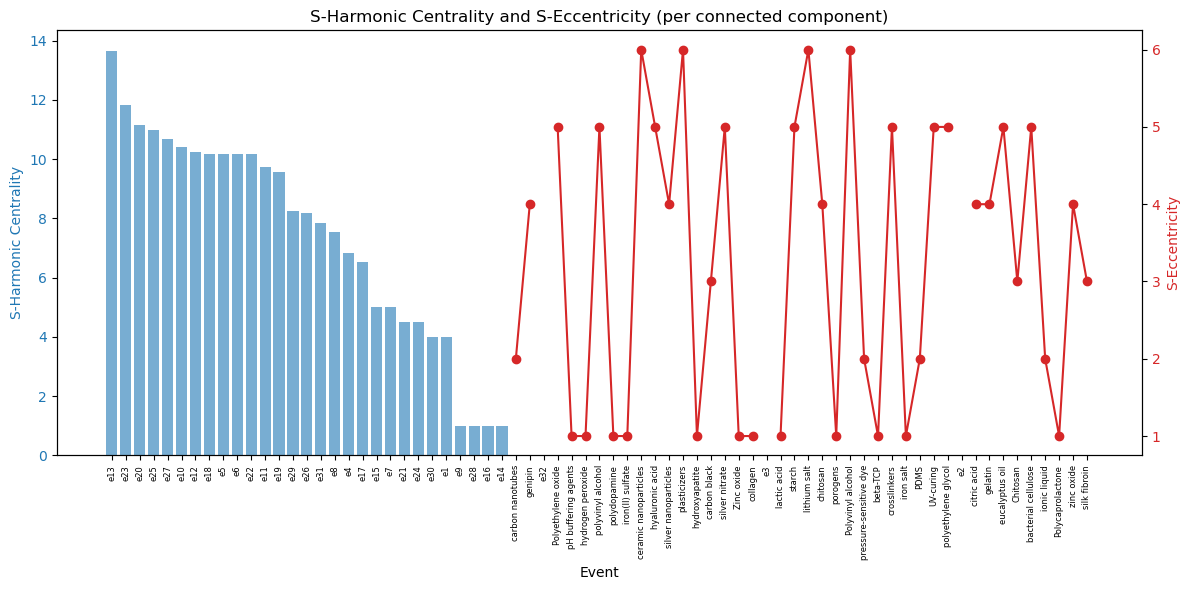

In [28]:
import networkx as nx
from hypernetx.algorithms.s_centrality_measures import s_harmonic_centrality
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Get s-line graph
s = 1
line_graph = H.get_linegraph(s=s, edges=False)

# Step 2: Compute harmonic centrality (can be on full graph)
harm_centrality = s_harmonic_centrality(H, s=s)

# Step 3: Compute eccentricity on connected components
ecc_centrality = {}
for component in nx.connected_components(line_graph):
    subgraph = line_graph.subgraph(component)
    ecc_sub = nx.eccentricity(subgraph)
    ecc_centrality.update(ecc_sub)

# Step 4: Create DataFrame
df = pd.DataFrame([
    {
        "Event": node,
        "S-Harmonic Centrality": harm_centrality.get(node, 0.0),
        "S-Eccentricity": ecc_centrality.get(node, float("inf"))
    }
    for node in set(harm_centrality) | set(ecc_centrality)
])

# Step 5: Plot
df_sorted = df.sort_values(by="S-Harmonic Centrality", ascending=False)
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel("Event")
ax1.set_ylabel("S-Harmonic Centrality", color='tab:blue')
ax1.bar(df_sorted["Event"], df_sorted["S-Harmonic Centrality"], color='tab:blue', alpha=0.6)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(range(len(df_sorted["Event"])))
ax1.set_xticklabels(df_sorted["Event"], rotation=90, fontsize=6)

ax2 = ax1.twinx()
ax2.set_ylabel("S-Eccentricity", color='tab:red')
ax2.plot(df_sorted["S-Eccentricity"].values, color='tab:red', marker='o')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("S-Harmonic Centrality and S-Eccentricity (per connected component)")
plt.tight_layout()
plt.show()

